## Hyphotesis## 

Given the past seasons, what is the realistic probability that each team could win the next season 

1. Who is mostly like to win the premier based on the previous 10 years 
2. Who are the teams that will most likely be relegated 
3. What are the teams that get erupoen spots: top 5(CL), 6 (EL), 7(ConL)

In [50]:
import pandas as pd

full_data = pd.read_csv("prem_2014_2025.csv")

In [51]:

pd.set_option('display.max_columns', 500)
pd.set_option('display.max_rows', 500)

In [52]:
print(full_data.shape)
full_data.tail(20)

(220, 20)


,rk,squad,mp,w,d,l,gf,ga,gd,pts,pts/mp,attendance,top_team_scorer,goalkeeper,notes,season,xg,xga,xgd,xgd/90
200,1,Liverpool,38,25,9,4,86,41,45,84,2.21,60324,Mohamed Salah - 29,Alisson,→ Champions League via league finish,2024,82.2,38.6,43.6,1.15
201,2,Arsenal,38,20,14,4,69,34,35,74,1.95,60251,Kai Havertz - 9,David Raya,→ Champions League via league finish,2024,59.9,34.4,25.5,0.67
202,3,Manchester City,38,21,8,9,72,44,28,71,1.87,52756,Erling Haaland - 22,Ederson,→ Champions League via league finish,2024,68.1,47.7,20.4,0.54
203,4,Chelsea,38,20,9,9,64,43,21,69,1.82,39672,Cole Palmer - 15,Robert Sánchez,→ Champions League via league finish,2024,67.8,47.3,20.5,0.54
204,5,Newcastle Utd,38,20,6,12,68,47,21,66,1.74,52187,Alexander Isak - 23,Nick Pope,→ Champions League via league finish,2024,63.8,45.5,18.3,0.48
205,6,Aston Villa,38,19,9,10,58,51,7,66,1.74,42079,Ollie Watkins - 16,Emiliano Martínez,→ Europa League via league finish,2024,56.1,50.1,5.9,0.16
206,7,Nott'ham Forest,38,19,8,11,58,46,12,65,1.71,30059,Chris Wood - 20,Matz Sels,→ Conference League via league finish,2024,45.5,48.9,-3.4,-0.09
207,8,Brighton,38,16,13,9,66,59,7,61,1.61,31798,"Danny Welbeck, Kaoru Mitoma... - 10",Bart Verbruggen,NaN,2024,58.7,54.6,4.1,0.11
208,9,Bournemouth,38,15,11,12,58,46,12,56,1.47,11210,Justin Kluivert - 12,Kepa Arrizabalaga,NaN,2024,64.0,48.5,15.5,0.41
209,10,Brentford,38,16,8,14,66,57,9,56,1.47,18742,Bryan Mbeumo - 20,Mark Flekken,NaN,2024,59.0,55.4,3.6,0.09


In [53]:

# Filter out the 2024/25 season
filtered_data = full_data[full_data['season'] != 2024]
# number of appearances for the past 10 seasons 
# if below 10 then the team was relegated at some point
filtered_data['squad'].value_counts()


squad
Chelsea            10
Everton            10
Arsenal            10
Manchester Utd     10
Tottenham          10
Liverpool          10
Manchester City    10
West Ham           10
Crystal Palace     10
Leicester City      9
Newcastle Utd       9
Southampton         9
Burnley             8
Brighton            7
Aston Villa         7
Bournemouth         7
Wolves              6
Watford             6
West Brom           5
Stoke City          4
Swansea City        4
Fulham              4
Leeds United        3
Sheffield Utd       3
Brentford           3
Norwich City        3
Sunderland          3
Nott'ham Forest     2
Hull City           2
Huddersfield        2
Cardiff City        1
Middlesbrough       1
QPR                 1
Luton Town          1
Name: count, dtype: int64

In [54]:

# Top 3 ranking count per team
filtered_data['squad'].groupby(full_data['rk']).value_counts().head(10)

rk  squad          
1   Manchester City    6
    Chelsea            2
    Leicester City     1
    Liverpool          1
2   Arsenal            3
    Liverpool          2
    Manchester City    2
    Manchester Utd     2
    Tottenham          1
3   Chelsea            2
Name: count, dtype: int64

In [55]:
filtered_data.describe()


,rk,mp,w,d,l,gf,ga,gd,pts,pts/mp,attendance,season,xg,xga,xgd,xgd/90
count,200.000000,200.0,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,140.000000,140.000000,140.000000,140.000000
mean,10.500000,38.0,14.570000,8.860000,14.570000,53.070000,53.070000,0.000000,52.510000,1.381850,33353.970000,2018.500000,51.888571,51.891429,-0.004286,-0.000214
std,5.780751,0.0,6.305067,2.833823,5.906737,17.730963,13.690223,28.316588,18.126299,0.476947,18755.345392,2.879489,13.737687,11.270797,22.639266,0.596241
min,1.000000,38.0,3.000000,2.000000,1.000000,20.000000,22.000000,-69.000000,16.000000,0.420000,178.000000,2014.000000,28.800000,23.800000,-43.200000,-1.140000
25%,5.750000,38.0,10.000000,7.000000,11.000000,40.000000,44.000000,-20.000000,40.000000,1.050000,20748.500000,2016.000000,41.200000,45.700000,-17.400000,-0.460000
50%,10.500000,38.0,13.000000,9.000000,15.000000,49.500000,53.000000,-6.000000,48.500000,1.275000,31219.000000,2018.500000,49.350000,52.550000,-3.400000,-0.090000
75%,15.250000,38.0,19.000000,11.000000,19.000000,63.500000,63.000000,18.000000,65.250000,1.717500,44835.500000,2021.000000,58.975000,59.450000,14.675000,0.382500
max,20.000000,38.0,32.000000,17.000000,29.000000,106.000000,104.000000,79.000000,100.000000,2.630000,75335.000000,2023.000000,92.000000,78.000000,64.000000,1.680000


In [56]:
####### Winning teams of the past 10 years

# Filter the dataset for teams that finished 1st each season
winning_teams = filtered_data[filtered_data["rk"] == 1][["season", "squad", "pts", "pts/mp", "gd"]].sort_values("season")

# Display the results
print(winning_teams)

     season            squad  pts  pts/mp  gd
0      2014          Chelsea   87    2.29  41
20     2015   Leicester City   81    2.13  32
40     2016          Chelsea   93    2.45  52
60     2017  Manchester City  100    2.63  79
80     2018  Manchester City   98    2.58  72
100    2019        Liverpool   99    2.61  52
120    2020  Manchester City   86    2.26  51
140    2021  Manchester City   93    2.45  73
160    2022  Manchester City   89    2.34  61
180    2023  Manchester City   91    2.39  62


In [57]:
avg_pts_mp_winners = winning_teams["pts/mp"].mean()

# Display the result
print(f"Average Pts/MP for past 10 winning teams (excluding this year): {avg_pts_mp_winners:.2f}")

Average Pts/MP for past 10 winning teams (excluding this year): 2.41


In [58]:

# Convert 'rk' to binary (1 if team won the league, 0 otherwise)
full_data["is_champion"] = (full_data["rk"] == 1).astype(int)

# Filter only championship-winning teams
champions_only = full_data[full_data["is_champion"] == 1]

In [59]:
full_data.head(2)


,rk,squad,mp,w,d,l,gf,ga,gd,pts,pts/mp,attendance,top_team_scorer,goalkeeper,notes,season,xg,xga,xgd,xgd/90,is_champion
0,1,Chelsea,38,26,9,3,73,32,41,87,2.29,41546,Diego Costa - 20,Thibaut Courtois,→ Champions League via league finish,2014,NaN,NaN,NaN,NaN,1
1,2,Manchester City,38,24,7,7,83,38,45,79,2.08,45365,Sergio Agüero - 26,Joe Hart,→ Champions League via league finish,2014,NaN,NaN,NaN,NaN,0


In [60]:
# Calculate the mean of 'pts/mp'
champions_only_filtered = champions_only[champions_only['season'] != 2024]

# Calculate the mean of 'pts/mp'
mean_pts_mp = champions_only_filtered["pts/mp"].mean()

print(f"Mean of 'pts/mp': {mean_pts_mp:.2f}")

Mean of 'pts/mp': 2.41


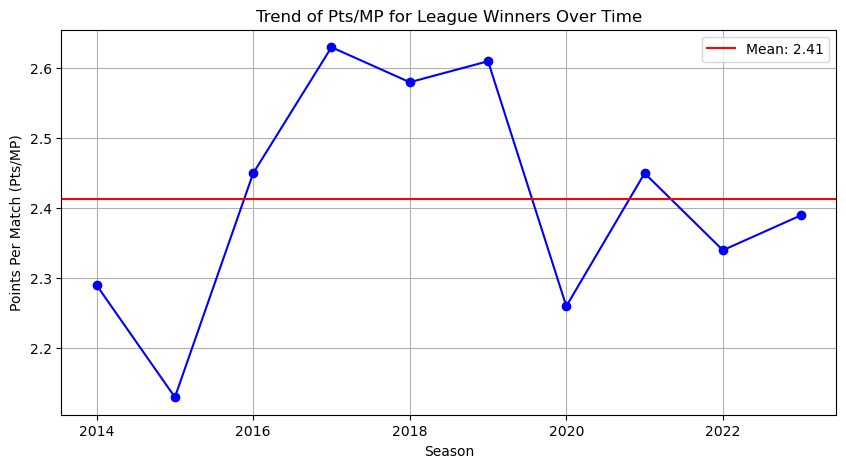

In [61]:

import matplotlib.pyplot as plt

# Plot trend of 'pts/mp' for champions over the years
plt.figure(figsize=(10, 5))
plt.plot(champions_only_filtered["season"], champions_only_filtered["pts/mp"], marker="o", linestyle="-", color="b")
plt.axhline(y=mean_pts_mp, color='r', linestyle='-', label=f'Mean: {mean_pts_mp:.2f}')
plt.xlabel("Season")
plt.ylabel("Points Per Match (Pts/MP)")
plt.title("Trend of Pts/MP for League Winners Over Time")
plt.grid(True)
plt.legend()
plt.show()


In [62]:

from sklearn.ensemble import RandomForestClassifier  # Machine learning model
from sklearn.preprocessing import StandardScaler     # To normalize our features
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, log_loss  # Model evaluation
from sklearn.model_selection import cross_val_score  # For cross-validation
import pandas as pd                                  # For data manipulation
import numpy as np                           

In [63]:

full_data.tail(3)

,rk,squad,mp,w,d,l,gf,ga,gd,pts,pts/mp,attendance,top_team_scorer,goalkeeper,notes,season,xg,xga,xgd,xgd/90,is_champion
217,18,Leicester City,38,6,7,25,33,80,-47,25,0.66,31448,Jamie Vardy - 9,Mads Hermansen,Relegated,2024,32.6,71.9,-39.3,-1.03,0
218,19,Ipswich Town,38,4,10,24,36,82,-46,22,0.58,29742,Liam Delap - 12,Arijanet Muric,Relegated,2024,34.4,72.7,-38.3,-1.01,0
219,20,Southampton,38,2,6,30,26,86,-60,12,0.32,30882,Paul Onuachu - 4,Aaron Ramsdale,Relegated,2024,32.7,84.8,-52.1,-1.37,0


In [64]:
# Create a simulated "first 5 games" dataset for 2024/25 season
# This will scale down the current season stats proportionally

# First, let's create the simulated early season data
df_test_10_games = full_data[full_data["season"] == 2024].copy()

# Scale down stats to represent first 5 games (5/38 of full season)
games_ratio = 10 / 38

# Adjust the stats proportionally for 5 games
df_test_10_games["mp"] = 10  # Matches played = 5
df_test_10_games["w"] = (df_test_10_games["w"] * games_ratio).round().astype(int)
df_test_10_games["d"] = (df_test_10_games["d"] * games_ratio).round().astype(int)  
df_test_10_games["l"] = (df_test_10_games["l"] * games_ratio).round().astype(int)
df_test_10_games["gf"] = (df_test_10_games["gf"] * games_ratio).round().astype(int)
df_test_10_games["ga"] = (df_test_10_games["ga"] * games_ratio).round().astype(int)
df_test_10_games["gd"] = df_test_10_games["gf"] - df_test_10_games["ga"]
df_test_10_games["pts"] = (df_test_10_games["w"] * 3 + df_test_10_games["d"]).astype(int)
df_test_10_games["pts/mp"] = df_test_10_games["pts"] / 5

# Ensure W + D + L = 5 for each team (fix any rounding issues)
for idx in df_test_10_games.index:
    total_games = df_test_10_games.loc[idx, "w"] + df_test_10_games.loc[idx, "d"] + df_test_10_games.loc[idx, "l"]
    if total_games != 5:
        # Adjust draws to make total = 5
        df_test_10_games.loc[idx, "d"] += (5 - total_games)
        # Recalculate points
        df_test_10_games.loc[idx, "pts"] = df_test_10_games.loc[idx, "w"] * 3 + df_test_10_games.loc[idx, "d"]
        df_test_10_games.loc[idx, "pts/mp"] = df_test_10_games.loc[idx, "pts"] / 5

# Define features for regression (predicting final points)
features = ["pts/mp", "gd", "w", "l", "gf", "ga", "attendance"]

# Training data: seasons before 2024
df_train = full_data[full_data["season"] < 2024]
X_train = df_train[features]
y_train = df_train["pts"]  # Target: final points

# Testing data: First 5 games of 2024/25 season
X_test_5_games = df_test_10_games[features]

print(f"Training data shape: {X_train.shape}")
print(f"Test data shape (5 games): {X_test_5_games.shape}")
print(f"Available teams in 2024/25 (5 games): {df_test_10_games['squad'].tolist()}")

print(f"\nSample of first 5 games data:")
print(df_test_10_games[["squad", "mp", "w", "d", "l", "gf", "ga", "gd", "pts", "pts/mp"]].head())


Training data shape: (200, 7)
Test data shape (5 games): (20, 7)
Available teams in 2024/25 (5 games): ['Liverpool', 'Arsenal', 'Manchester City', 'Chelsea', 'Newcastle Utd', 'Aston Villa', "Nott'ham Forest", 'Brighton', 'Bournemouth', 'Brentford', 'Fulham', 'Crystal Palace', 'Everton', 'West Ham', 'Manchester Utd', 'Wolves', 'Tottenham', 'Leicester City', 'Ipswich Town', 'Southampton']

Sample of first 5 games data:
               squad  mp  w  d  l  gf  ga  gd  pts  pts/mp
200        Liverpool  10  7 -3  1  23  11  12   18     3.6
201          Arsenal  10  5 -1  1  18   9   9   14     2.8
202  Manchester City  10  6 -3  2  19  12   7   15     3.0
203          Chelsea  10  5 -2  2  17  11   6   13     2.6
204    Newcastle Utd  10  5 -3  3  18  12   6   12     2.4


In [65]:

# Initialize the model with 200 trees and a fixed random state for reproducibility
model = RandomForestClassifier(n_estimators=200, random_state=42)

# Train the model on the training data
model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [66]:
# Predict final points on training set
train_preds = model.predict(X_train)

# Predict probabilities of being champion
train_probs = model.predict_proba(X_train)[:, 1]

In [67]:
# Predict final points for 2024/25 season based on first 5 games
df_test_10_games["predicted_points"] = model.predict(X_test_5_games)

In [68]:

df_test.head()


,rk,squad,mp,w,d,l,gf,ga,gd,pts,pts/mp,attendance,top_team_scorer,goalkeeper,notes,season,xg,xga,xgd,xgd/90,is_champion,projected_pts,predicted_points,predicted_position
200,1,Liverpool,38,25,9,4,86,41,45,84,2.21,60324,Mohamed Salah - 29,Alisson,→ Champions League via league finish,2024,82.2,38.6,43.6,1.15,1,83.98,82,1
201,2,Arsenal,38,20,14,4,69,34,35,74,1.95,60251,Kai Havertz - 9,David Raya,→ Champions League via league finish,2024,59.9,34.4,25.5,0.67,0,74.10,71,2
202,3,Manchester City,38,21,8,9,72,44,28,71,1.87,52756,Erling Haaland - 22,Ederson,→ Champions League via league finish,2024,68.1,47.7,20.4,0.54,0,71.06,71,3
203,4,Chelsea,38,20,9,9,64,43,21,69,1.82,39672,Cole Palmer - 15,Robert Sánchez,→ Champions League via league finish,2024,67.8,47.3,20.5,0.54,0,69.16,69,4
204,5,Newcastle Utd,38,20,6,12,68,47,21,66,1.74,52187,Alexander Isak - 23,Nick Pope,→ Champions League via league finish,2024,63.8,45.5,18.3,0.48,0,66.12,66,5


In [69]:

# Round predicted points for better readability
df_test_10_games["predicted_points"] = df_test_10_games["predicted_points"].round(1)

# Sort by predicted points to create league table
df_test_10_games = df_test_10_games.sort_values("predicted_points", ascending=False)
df_test_10_games["predicted_position"] = range(1, len(df_test_10_games) + 1)


In [70]:
# Create a nice formatted table
predicted_table = df_test_10_games[["predicted_position", "squad", "predicted_points", "pts/mp", "gd", "w", "l"]].copy()
predicted_table.columns = ["Pos", "Team", "Predicted Pts", "Pts/MP", "GD", "W", "L"]

print(predicted_table.to_string(index=False))

# Show top 4 (Champions League) and relegation zone
print(f"\nChampions League spots (Top 4):")
print(predicted_table.head(4)[["Pos", "Team", "Predicted Pts"]].to_string(index=False))

print(f"\nEuropa League spots (5th-6th):")
print(predicted_table.iloc[4:6][["Pos", "Team", "Predicted Pts"]].to_string(index=False))

print(f"\nRelegation zone (Bottom 3):")
print(predicted_table.tail(3)[["Pos", "Team", "Predicted Pts"]].to_string(index=False))

 Pos            Team  Predicted Pts  Pts/MP  GD  W  L
   1       Liverpool             51     3.6  12  7  1
   2     Bournemouth             51     2.0   3  4  3
   3          Wolves             51     1.2  -4  3  5
   4        West Ham             51     1.4  -4  3  4
   5         Everton             51     1.6  -1  3  3
   6  Crystal Palace             51     1.6   0  3  3
   7         Arsenal             51     2.8   9  5  1
   8       Brentford             51     1.8   2  4  4
   9          Fulham             51     1.8   0  4  4
  10        Brighton             51     2.2   1  4  2
  11 Nott'ham Forest             51     2.4   3  5  3
  12     Aston Villa             51     2.4   2  5  3
  13   Newcastle Utd             51     2.4   6  5  3
  14         Chelsea             51     2.6   6  5  2
  15 Manchester City             51     3.0   7  6  2
  16  Manchester Utd             47     1.2  -2  3  5
  17       Tottenham             38     1.0   0  3  6
  18  Leicester City        

In [71]:
# Extract actual 2024/25 season data
actual_2024 = full_data[full_data['season'] == 2024].copy()
actual_2024 = actual_2024.sort_values('rk')  # Sort by actual position
actual_2024 = actual_2024[['squad', 'rk', 'pts']].copy()
actual_2024.columns = ['team', 'actual_position', 'actual_points']

print("Actual 2024/25 Season Results:")
print(actual_2024)


Actual 2024/25 Season Results:
                team  actual_position  actual_points
200        Liverpool                1             84
201          Arsenal                2             74
202  Manchester City                3             71
203          Chelsea                4             69
204    Newcastle Utd                5             66
205      Aston Villa                6             66
206  Nott'ham Forest                7             65
207         Brighton                8             61
208      Bournemouth                9             56
209        Brentford               10             56
210           Fulham               11             54
211   Crystal Palace               12             53
212          Everton               13             48
213         West Ham               14             43
214   Manchester Utd               15             42
215           Wolves               16             42
216        Tottenham               17             38
217   Leicester

In [72]:
# Prepare prediction data with standardized team names
predicted_2024 = df_test_10_games[['squad', 'predicted_position', 'predicted_points']].copy()
predicted_2024.columns = ['team', 'predicted_position', 'predicted_points']

# Create a mapping for team name standardization
team_name_mapping = {
    "Nott'ham Forest": "Nottingham Forest",
    "Manchester Utd": "Manchester United",
    "Newcastle Utd": "Newcastle United"
}

# Apply team name standardization
predicted_2024['team'] = predicted_2024['team'].replace(team_name_mapping)
actual_2024['team'] = actual_2024['team'].replace(team_name_mapping)

print("Predicted 2024/25 Season Results:")
print(predicted_2024)


Predicted 2024/25 Season Results:
                  team  predicted_position  predicted_points
200          Liverpool                   1                51
208        Bournemouth                   2                51
215             Wolves                   3                51
213           West Ham                   4                51
212            Everton                   5                51
211     Crystal Palace                   6                51
201            Arsenal                   7                51
209          Brentford                   8                51
210             Fulham                   9                51
207           Brighton                  10                51
206  Nottingham Forest                  11                51
205        Aston Villa                  12                51
204   Newcastle United                  13                51
203            Chelsea                  14                51
202    Manchester City                  15         

In [73]:
# Merge predicted and actual data
comparison_data = pd.merge(actual_2024, predicted_2024, on='team', how='inner')
comparison_data = comparison_data.sort_values('actual_position')  # Order by actual position

print("Comparison Data:")
print(comparison_data)


Comparison Data:
                 team  actual_position  actual_points  predicted_position  \
0           Liverpool                1             84                   1   
1             Arsenal                2             74                   7   
2     Manchester City                3             71                  15   
3             Chelsea                4             69                  14   
4    Newcastle United                5             66                  13   
5         Aston Villa                6             66                  12   
6   Nottingham Forest                7             65                  11   
7            Brighton                8             61                  10   
8         Bournemouth                9             56                   2   
9           Brentford               10             56                   8   
10             Fulham               11             54                   9   
11     Crystal Palace               12             53      

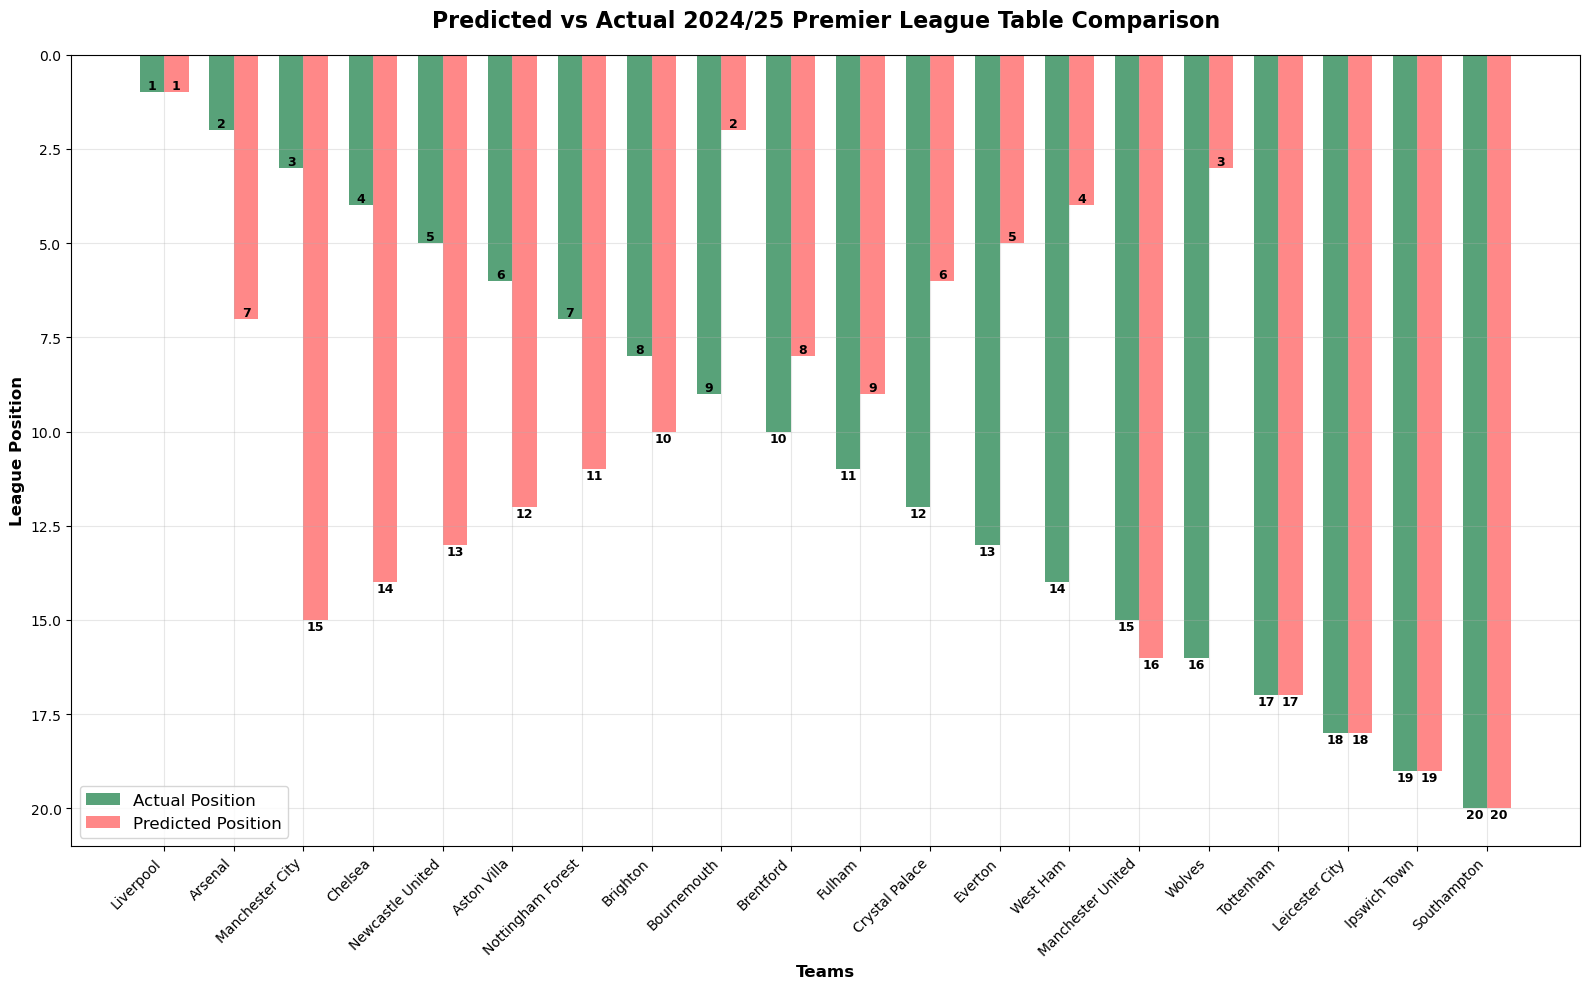

In [74]:
# Create the comparison bar graph
import matplotlib.pyplot as plt
import numpy as np

# Set up the plot
fig, ax = plt.subplots(figsize=(16, 10))

# Create x positions for teams
x = np.arange(len(comparison_data))
width = 0.35

# Create bars
bars1 = ax.bar(x - width/2, comparison_data['actual_position'], width, 
               label='Actual Position', color='#2E8B57', alpha=0.8)
bars2 = ax.bar(x + width/2, comparison_data['predicted_position'], width, 
               label='Predicted Position', color='#FF6B6B', alpha=0.8)

# Customize the plot
ax.set_xlabel('Teams', fontsize=12, fontweight='bold')
ax.set_ylabel('League Position', fontsize=12, fontweight='bold')
ax.set_title('Predicted vs Actual 2024/25 Premier League Table Comparison', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(comparison_data['team'], rotation=45, ha='right')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

# Invert y-axis so position 1 (best) is at the top
ax.invert_yaxis()

# Add value labels on bars
def add_value_labels(bars, positions):
    for bar, pos in zip(bars, positions):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(pos)}', ha='center', va='bottom' if pos < 10 else 'top',
                fontsize=9, fontweight='bold')

add_value_labels(bars1, comparison_data['actual_position'])
add_value_labels(bars2, comparison_data['predicted_position'])

# Adjust layout to prevent label cutoff
plt.tight_layout()
plt.show()


In [75]:
# Calculate prediction accuracy metrics
comparison_data['position_error'] = abs(comparison_data['predicted_position'] - comparison_data['actual_position'])
comparison_data['points_error'] = abs(comparison_data['predicted_points'] - comparison_data['actual_points'])

# Overall accuracy metrics
mean_absolute_error_position = comparison_data['position_error'].mean()
mean_absolute_error_points = comparison_data['points_error'].mean()

# Count exact predictions
exact_position_predictions = (comparison_data['position_error'] == 0).sum()
exact_position_accuracy = exact_position_predictions / len(comparison_data) * 100

# Count predictions within 1 position
within_1_position = (comparison_data['position_error'] <= 1).sum()
within_1_position_accuracy = within_1_position / len(comparison_data) * 100

# Count predictions within 3 positions
within_3_positions = (comparison_data['position_error'] <= 3).sum()
within_3_positions_accuracy = within_3_positions / len(comparison_data) * 100

print("=== PREDICTION ACCURACY ANALYSIS ===")
print(f"Mean Absolute Error (Position): {mean_absolute_error_position:.2f}")
print(f"Mean Absolute Error (Points): {mean_absolute_error_points:.2f}")
print(f"\nExact Position Predictions: {exact_position_predictions}/20 ({exact_position_accuracy:.1f}%)")
print(f"Within 1 Position: {within_1_position}/20 ({within_1_position_accuracy:.1f}%)")
print(f"Within 3 Positions: {within_3_positions}/20 ({within_3_positions_accuracy:.1f}%)")


=== PREDICTION ACCURACY ANALYSIS ===
Mean Absolute Error (Position): 4.80
Mean Absolute Error (Points): 10.65

Exact Position Predictions: 5/20 (25.0%)
Within 1 Position: 6/20 (30.0%)
Within 3 Positions: 9/20 (45.0%)


In [76]:
# Identify biggest prediction errors
print("\n=== BIGGEST PREDICTION ERRORS ===")
biggest_errors = comparison_data.nlargest(5, 'position_error')[['team', 'actual_position', 'predicted_position', 'position_error']]
print("Top 5 Biggest Position Errors:")
print(biggest_errors.to_string(index=False))

print("\n=== MOST ACCURATE PREDICTIONS ===")
most_accurate = comparison_data[comparison_data['position_error'] == 0][['team', 'actual_position', 'predicted_position']]
if len(most_accurate) > 0:
    print("Exact Predictions:")
    print(most_accurate.to_string(index=False))
else:
    print("No exact predictions found.")



=== BIGGEST PREDICTION ERRORS ===
Top 5 Biggest Position Errors:
            team  actual_position  predicted_position  position_error
          Wolves               16                   3              13
 Manchester City                3                  15              12
         Chelsea                4                  14              10
        West Ham               14                   4              10
Newcastle United                5                  13               8

=== MOST ACCURATE PREDICTIONS ===
Exact Predictions:
          team  actual_position  predicted_position
     Liverpool                1                   1
     Tottenham               17                  17
Leicester City               18                  18
  Ipswich Town               19                  19
   Southampton               20                  20


In [77]:
# Create a detailed comparison table
print("\n=== DETAILED COMPARISON TABLE ===")
detailed_comparison = comparison_data[['team', 'actual_position', 'predicted_position', 'position_error', 
                                     'actual_points', 'predicted_points', 'points_error']].copy()
detailed_comparison.columns = ['Team', 'Actual Pos', 'Predicted Pos', 'Pos Error', 
                               'Actual Pts', 'Predicted Pts', 'Pts Error']
detailed_comparison = detailed_comparison.sort_values('Actual Pos')

print(detailed_comparison.to_string(index=False))



=== DETAILED COMPARISON TABLE ===
             Team  Actual Pos  Predicted Pos  Pos Error  Actual Pts  Predicted Pts  Pts Error
        Liverpool           1              1          0          84             51         33
          Arsenal           2              7          5          74             51         23
  Manchester City           3             15         12          71             51         20
          Chelsea           4             14         10          69             51         18
 Newcastle United           5             13          8          66             51         15
      Aston Villa           6             12          6          66             51         15
Nottingham Forest           7             11          4          65             51         14
         Brighton           8             10          2          61             51         10
      Bournemouth           9              2          7          56             51          5
        Brentford        